# Ejercicio 3 - Práctica 6 - Parte 2

El dataset `penguins` es un conjunto de datos sobre pingüinos de tres especies diferentes que anidan en una colonia de Archipiélago Palmer, en la Antártida. Contiene información sobre las medidas corporales de los pingüinos, incluyendo la longitud y profundidad del pico (`bill_length_mm` y `bill_depth_mm`, respectivamente), la longitud de la aleta (`flipper_length_mm`) y la masa corporal (`body_mass_g`), así como información sobre el sexo.

1. Realice un gráfico que le permita visualizar la relación que existe entre la longitud del pico y la longitud de la aleta de los pingüinos Palmer, según la especie. ¿Qué observa?

2. Ajuste un modelo de regresión lineal que le permita predecir la longitud promedio del pico de los pingüinos Palmer a partir de la longitud de la aleta (**modelo 1**).

3. A partir de las observaciones que realizó en el ítem 1, introduzca alguna modificación sobre el modelo inicial que le permita mejorar su capacidad predictiva para la longitud del pico de los pingüinos. Ajuste el nuevo modelo propuesto (**modelo 2**).

4. ¿Cuál de los dos modelos (**modelo 1**, **modelo 2**) proporciona un mejor ajuste? ¿Qué métrica utilizó para compararlos?

5. Utilice el modelo seleccionado en el ítem anterior para predecir la longitud de pico que tendrá un pingüino Chinstrap de 17.6 mm de profundidad de pico, 191 mm de longitud de aleta, 3125 g de masa corporal y sexo masculino.

---

## Cargamos los datos

In [1]:
# Importamos librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm, kurtosis
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy.stats import chi2

In [2]:
# Nos quedamos únicamente con los casos completos
data_penguins = sns.load_dataset('penguins').dropna()
data_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## Ítem 1 

Realice un gráfico que le permita visualizar la relación que existe entre la longitud del pico y la longitud de la aleta de los pingüinos Palmer, según la especie. ¿Qué observa?


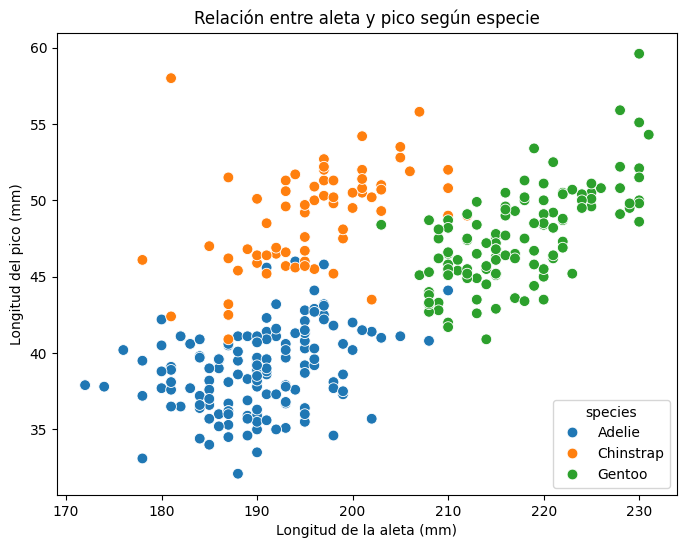

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=data_penguins, x="flipper_length_mm", y="bill_length_mm",
                hue="species", s=60)

plt.xlabel("Longitud de la aleta (mm)")
plt.ylabel("Longitud del pico (mm)")
plt.title("Relación entre aleta y pico según especie")

plt.show()

Se observa una relación positiva entre la longitud del pico y la longitud de la aleta en los pingüinos Palmer. Sin embargo, esta relación está fuertemente estructurada por especie, ya que cada una presenta rangos distintos de valores, formando agrupamientos diferenciados. Esto sugiere que la especie es un factor explicativo relevante en la relación entre ambas variables.

## Ítem 2

Ajuste un modelo de regresión lineal que le permita predecir la longitud promedio del pico de los pingüinos Palmer a partir de la longitud de la aleta (**modelo 1**).

In [11]:
# Ajustamos modelo de regresión lineal simple (un único predictor)
modelo1 = smf.ols(formula = 'bill_length_mm ~ flipper_length_mm', data = data_penguins).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:         bill_length_mm   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     246.2
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           7.21e-42
Time:                        12:33:01   Log-Likelihood:                -945.20
No. Observations:                 333   AIC:                             1894.
Df Residuals:                     331   BIC:                             1902.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -7.2186      3.27

La ecuación del modelo 1 ajustado es:

$$Y = -7.2186 + 0.2548X,$$

siendo $X$ la longiutd de la aleta.

Este modelo explica el 42.7% de la variabilidad en la longitud del pico ($R^2 = 0.427). Hay dispersión alrededor de la recta.

 Su representación gráfica:

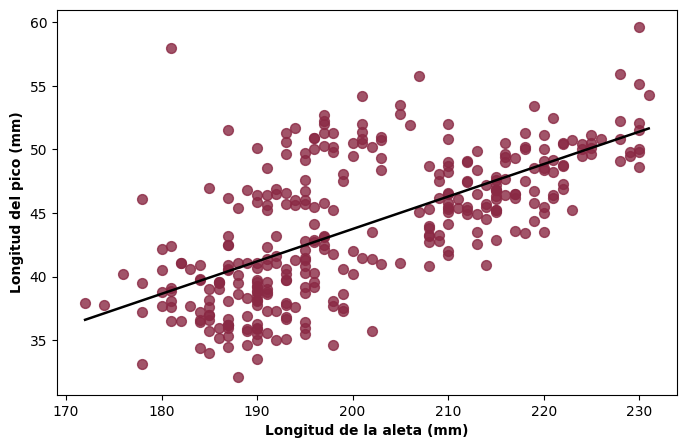

In [13]:
fig, ax = plt.subplots(figsize = (8, 5))

sns.regplot(x = 'flipper_length_mm', y = 'bill_length_mm', data = data_penguins,
            scatter_kws = {'color': '#8a2944', 'edgecolor': None, 's': 50},
            line_kws = {'color': 'black', 'linewidth': 1.8},
            ci = None,
            ax = ax)

ax.set_xlabel('Longitud de la aleta (mm)', fontweight = 'bold')
ax.set_ylabel('Longitud del pico (mm)', fontweight = 'bold')

plt.show()

# Ítem 3

A partir de las observaciones que realizó en el ítem 1, introduzca alguna modificación sobre el modelo inicial que le permita mejorar su capacidad predictiva para la longitud del pico de los pingüinos. Ajuste el nuevo modelo propuesto (**modelo 2**).

En lugar de utilizar únicamente la longitud de la aleta como predictor, incluimos también la especie como una variable categórica con tres niveles (Adelie, Chinstrap y Gentoo). Por ejemplo, tomando Adelie como categoría de referencia, el modelo queda:

$$Y = \beta_0 + \beta_1X + \beta_2C1 + \beta_3C2 + \epsilon$$

donde
- $C_1 = 1$ si la especie es Chinstrap, $0$ en caso contrario
- $C_2 = 1$ si la especie es Gentoo, $0$ en caso contrario

In [16]:
modelo2 = smf.ols(formula = 'bill_length_mm ~ flipper_length_mm + species', data = data_penguins).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:         bill_length_mm   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     380.8
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          1.23e-106
Time:                        12:41:54   Log-Likelihood:                -788.37
No. Observations:                 333   AIC:                             1585.
Df Residuals:                     329   BIC:                             1600.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -2.4802 

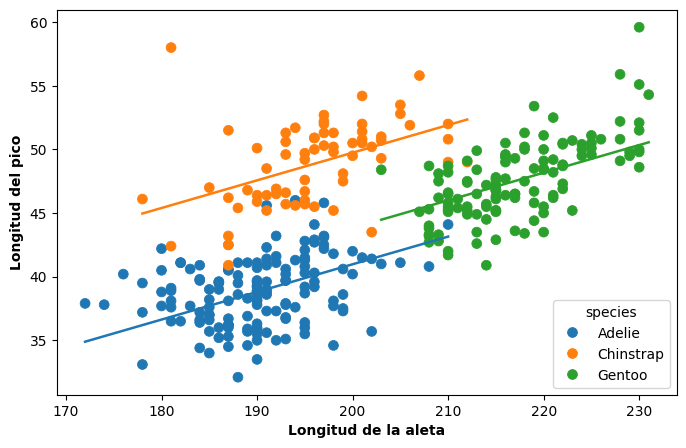

In [17]:
# Primero generamos los valores predichos de la respuesta para los registros del dataset
data_penguins['predichos'] = modelo2.predict(data_penguins)

# Luego los utilizamos para representar las rectas
fig, ax = plt.subplots(figsize = (8, 5))

sns.scatterplot(x = 'flipper_length_mm', y = 'bill_length_mm', hue = 'species', s = 50, data = data_penguins, 
                edgecolor = None, ax = ax)
sns.lineplot(x = 'flipper_length_mm', y = 'predichos', hue = 'species',linewidth = 1.8, data = data_penguins, 
                ax = ax, legend = False)

ax.set_xlabel('Longitud de la aleta', fontweight = 'bold')
ax.set_ylabel('Longitud del pico', fontweight = 'bold')

handles, _ = ax.get_legend_handles_labels()
plt.show()

A partir del gráfico de dispersión se observó que los datos no forman una única nube homogénea, sino que aparecen agrupados según la especie de pingüino. Esto sugiere que la especie influye sobre la longitud del pico. Por tal motivo se propuso un segundo modelo incorporando la variable categórica especie como predictor adicional.

## Ítem 4

¿Cuál de los dos modelos (**modelo 1**, **modelo 2**) proporciona un mejor ajuste? ¿Qué métrica utilizó para compararlos?

Para comparar ambos modelos se utilizó el coeficiente de determinación ajustado `Adj. R-squared`, ya que esta métrica tiene en cuenta la cantidad de variables explicativas incorporadas al modelo y penaliza la inclusión de predictores que no aportan información relevante.

El modelo 1 presenta `Adj. R-squared` $=0.425$, mientras que el modelo 2 presenta `Adj. R-squared` $=0.774$. Por lo tanto, el modelo 2 explica aproximadamente el 77.4% de la variabilidad observada en la longitud del pico, superando ampliamente al modelo 1.

## Ítem 5

Utilice el modelo seleccionado en el ítem anterior para predecir la longitud de pico que tendrá un pingüino Chinstrap de 17.6 mm de profundidad de pico, 191 mm de longitud de aleta, 3125 g de masa corporal y sexo masculino.

El modelo 2 es

$$Y = −2.4802+8.7669C_1​ + 2.8489C_2 + 0.2173X.$$

Para nuestos datos tomamos $X = 191$, $C_1 = 1$, $C_2 =0$, y obtenemos

$$Y = 47.791.$$